In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
training_data = pd.read_parquet("../data/processed/training_data_with_physics.parquet")
training_data[["AirTemp","TyreHealth"]].describe()

,AirTemp,TyreHealth
count,57754.000000,57754.000000
mean,25.139708,0.890208
std,3.881125,0.116097
min,14.200000,0.050112
25%,22.799999,0.849374
50%,25.200001,0.926193
75%,26.900000,0.970643
max,37.200001,1.000000


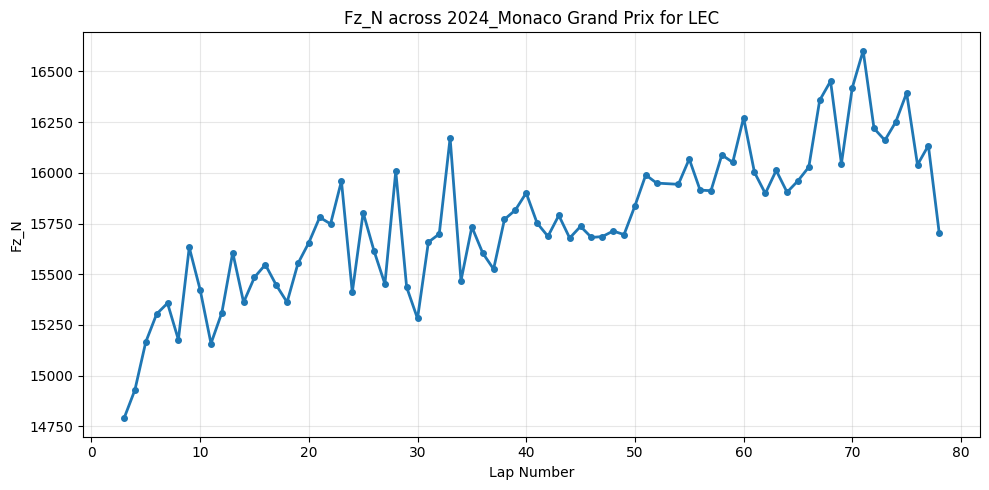

('2024_Monaco Grand Prix',
 'LEC',
        LapNumber          Fz_N
 30279          3  14789.520408
 30295          4  14929.494622
 30311          5  15165.838148
 30327          6  15303.927702
 30343          7  15357.247117)

In [4]:
# Visualise Fz_N across one race event for one driver.

required_cols = {"RaceID", "Driver", "LapNumber", "Fz_N"}
missing_cols = required_cols - set(training_data.columns)
if missing_cols:
    raise KeyError(f"Missing required columns: {sorted(missing_cols)}")

# Pick a race/driver pair with the most available Fz_N samples.
focus = (
    training_data.dropna(subset=["Fz_N"])
    .groupby(["RaceID", "Driver"], dropna=False)
    .size()
    .reset_index(name="n_laps")
    .sort_values(["n_laps", "RaceID", "Driver"], ascending=[False, True, True])
    .iloc[0]
 )

race_id = focus["RaceID"]
driver = focus["Driver"]

race_driver = (
    training_data.loc[
        (training_data["RaceID"] == race_id)
        & (training_data["Driver"] == driver)
    , ["LapNumber", "Fz_N"]]
    .dropna(subset=["LapNumber", "Fz_N"])
    .sort_values("LapNumber")
    .copy()
 )

plt.figure(figsize=(10, 5))
plt.plot(
    race_driver["LapNumber"],
    race_driver["Fz_N"],
    marker="o",
    linewidth=2,
    markersize=4,
    color="#1f77b4",
 )
plt.title(f"Fz_N across {race_id} for {driver}")
plt.xlabel("Lap Number")
plt.ylabel("Fz_N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

race_id, driver, race_driver.head()